## Correlation of Weather Data and Gas, Electric and The Rink

In [1]:
import requests
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv(r"D:\other-files\school\database_dev\Windigo Internship\HUBSPOT_KEY.env")

service_key = os.getenv("HUBSPOT_SERVICE_KEY")

if not service_key:
    raise ValueError("HUBSPOT_SERVICE_KEY was not loaded")

url = "https://api.hubapi.com/crm/v3/objects/contacts"

headers = {
    "Authorization": f"Bearer {service_key}"
}

response = requests.get(
    "https://api.hubapi.com/crm/v3/objects/contacts",
    headers=headers
)

properties = [
    "gas_read_date",
    "gas_billing_days",
    "natural_gas_used_therms",
    "heating_degree_days_gas",
    "cooling_degree_days_gas",

    "electricity_read_date",
    "electric_billing_days",
    "heating_degree_days",
    "cooling_degree_days",
    "onpeak_electricity_used_kwh",
    "offpeak_electricity_used_kwh",

    "date"
] + [f"ice_depth_zone__{i}" for i in range(1, 17)]

params = {
    "limit": 100,
    "properties": ",".join(properties)
}

hubspot_rows = []

while url:
    r = requests.get(url, headers=headers, params=params)
    r.raise_for_status()
    data = r.json()

    for item in data.get("results", []):
        props = item.get("properties", {})

        row = {
            "id": item.get("id")
        }

        for prop in properties:
            row[prop] = props.get(prop)

        hubspot_rows.append(row)

    url = data.get("paging", {}).get("next", {}).get("link")
    params = None

hubspot_df = pd.DataFrame(hubspot_rows)

gas_columns = [
    "gas_read_date",
    "gas_billing_days",
    "natural_gas_used_therms",
    "heating_degree_days_gas",
    "cooling_degree_days_gas"
]

electric_columns = [
    "electricity_read_date",
    "electric_billing_days",
    "heating_degree_days",
    "cooling_degree_days",
    "onpeak_electricity_used_kwh",
    "offpeak_electricity_used_kwh"
]

ice_depth_columns = ["date"] + [f"ice_depth_zone__{i}" for i in range(1, 17)]

gas_df = hubspot_df[gas_columns].copy()

electric_df = hubspot_df[electric_columns].copy()

ice_df = hubspot_df[ice_depth_columns].copy()

weather = pd.read_csv(r'D:\other-files\school\database_dev\The-Windigo-Data-Team-Summer-2026\Ice Depth Project\weather_data_final.csv')

columns = [
    "DATE",
    "Best_TMAX",
    "Best_TMIN",
    "Rel Humidity Max",
    "Rel Humidity Mean",
    "Dew Point Mean",
    "Wind Speed Max",
    "Wind Gusts Max",
    "Brookfield_PRCP",
    "Brookfield_SNWD",
    "Waukesha_SNOW"
]

# weather data
weather_df = pd.DataFrame(weather[columns])

weather_numeric_columns = [
    "Best_TMAX",
    "Best_TMIN",
    "Rel Humidity Max",
    "Rel Humidity Mean",
    "Dew Point Mean",
    "Wind Speed Max",
    "Wind Gusts Max",
    "Brookfield_PRCP",
    "Brookfield_SNWD",
    "Waukesha_SNOW"
]

for col in weather_numeric_columns:
    weather_df[col] = pd.to_numeric(
        weather_df[col], errors="coerce"
    )

weather_df["DATE"] = pd.to_datetime(
    weather_df["DATE"],
    errors="coerce"
)

#-----------------------
# Ice Rink Data
#-----------------------

# Convert empty strings to missing values
ice_df = ice_df.replace("", pd.NA)

# Remove rows where every ice depth field is blank
ice_depth_columns = [col for col in ice_df.columns if col.startswith("ice_depth_zone_")]

ice_df = ice_df.dropna(subset=ice_depth_columns, how="all")

ice_df["date"] = pd.to_datetime(
    ice_df["date"],
    errors="coerce"
)

zone_columns = [f"ice_depth_zone__{i}" for i in range(1,17)]

for col in zone_columns:
    ice_df[col] = pd.to_numeric(
        ice_df[col],
        errors="coerce"
    )

ice_df["average_ice_depth"] = (
    ice_df[zone_columns].mean(axis=1)
)

ice_df = ice_df.dropna(
    subset=["average_ice_depth"]
)

ice_df["ice_period_start"] = (ice_df["date"].shift(1) + pd.Timedelta(days=1))
ice_df["ice_period_end"] = (ice_df["ice_period_start"].fillna(ice_df["date"]))
ice_df["ice_period_end"] = ice_df["date"]

#-----------------------
# Gas data
#-----------------------

# Convert empty strings to missing values
gas_df = gas_df.replace("", pd.NA)
gas_df = gas_df.dropna(subset=["gas_read_date"], how="any")

gas_df["gas_read_date"] = pd.to_datetime(
    gas_df["gas_read_date"],
    errors="coerce"
)

gas_col_numeric = [
    "gas_billing_days",
    "natural_gas_used_therms",
    "heating_degree_days_gas",
    "cooling_degree_days_gas"
]

for col in gas_col_numeric:
    gas_df[col] = pd.to_numeric(gas_df[col], errors="coerce")

#--------------------
# Electricity Data
#--------------------

electric_df = electric_df.replace("", pd.NA)
electric_df = electric_df.dropna(subset=["electricity_read_date"], how="any")

electric_df["electricity_read_date"] = pd.to_datetime(
    electric_df["electricity_read_date"],
    errors="coerce"
)

electric_col_numeric = [
    "electric_billing_days",
    "heating_degree_days",
    "cooling_degree_days",
    "onpeak_electricity_used_kwh",
    "offpeak_electricity_used_kwh"
]

for col in electric_col_numeric:
    electric_df[col] = pd.to_numeric(electric_df[col], errors="coerce")

gas_df["gas_start_date"] = (
    gas_df["gas_read_date"]
    - pd.to_timedelta(
        gas_df["gas_billing_days"] - 1,
        unit="D"
    )
)

electric_df["electricity_start_date"] = (
    electric_df["electricity_read_date"]
    - pd.to_timedelta(
        electric_df["electric_billing_days"] - 1,
        unit="D"
    )
)

def summarize_weather_period(row, start_column, end_column):
    start_date = row[start_column]
    end_date = row[end_column]

    if pd.isna(start_date) or pd.isna(end_date):
        return pd.Series({
            "average_tmax": pd.NA,
            "average_tmin": pd.NA,
            "average_max_humidity": pd.NA,
            "average_humidity": pd.NA,
            "average_dew_point": pd.NA,
            "average_max_wind_speed": pd.NA,
            "max_wind_gusts": pd.NA,
            "total_precipitation": pd.NA,
            "average_snow_depth": pd.NA,
            "total_snowfall": pd.NA,
            "weather_days_found": 0
        })
    
    period_weather = weather_df[
        weather_df["DATE"].between(
            start_date,
            end_date,
            inclusive="both"
        )
    ]

    return pd.Series({
        "average_tmax": period_weather["Best_TMAX"].mean(),
        "average_tmin": period_weather["Best_TMIN"].mean(),
        "average_humidity": period_weather["Rel Humidity Mean"].mean(),
        "average_max_humidity": period_weather["Rel Humidity Max"].mean(),
        "average_dew_point": period_weather["Dew Point Mean"].mean(),
        "average_max_wind_speed": period_weather["Wind Speed Max"].mean(),
        "max_wind_gusts": period_weather["Wind Gusts Max"].max(),
        "total_precipitation": period_weather["Brookfield_PRCP"].fillna(0).sum(),
        "average_snow_depth": period_weather["Brookfield_SNWD"].mean(),
        "total_snowfall": period_weather["Waukesha_SNOW"].fillna(0).sum(),
        "weather_days_found": period_weather["DATE"].nunique()
    })

weather_summary_gas = gas_df.apply(
    summarize_weather_period,
    axis=1,
    start_column="gas_start_date",
    end_column="gas_read_date"
)

weather_summary_electric = electric_df.apply(
    summarize_weather_period,
    axis=1,
    start_column="electricity_start_date",
    end_column="electricity_read_date"
)

weather_summary_ice = ice_df.apply(
    summarize_weather_period,
    axis=1,
    start_column="ice_period_start",
    end_column="ice_period_end"
)


gas_df = pd.concat([gas_df.reset_index(drop=True), weather_summary_gas.reset_index(drop=True)], axis=1)
electric_df = pd.concat([electric_df.reset_index(drop=True), weather_summary_electric.reset_index(drop=True)], axis=1)
ice_df = pd.concat([ice_df.reset_index(drop=True), weather_summary_ice.reset_index(drop=True)], axis=1)

gas_df = gas_df.replace("", pd.NA)
gas_df = gas_df.dropna(subset=["average_tmax"], how="any").reset_index(drop=True)

electric_df = electric_df.replace("", pd.NA)
electric_df = electric_df.dropna(subset=["average_tmax"], how="any").reset_index(drop=True)

ice_df = ice_df.replace("", pd.NA)
ice_df = ice_df.dropna(subset=["average_tmax"], how="any").reset_index(drop=True)

In [27]:
from scipy.stats import linregress


def create_regression_table(dataframe, target_column):

    weather_columns = [
        "average_tmax",
        "average_tmin",
        "average_humidity",
        "average_max_humidity",
        "average_dew_point",
        "average_max_wind_speed",
        "max_wind_gusts",
        "total_precipitation",
        "average_snow_depth",
        "total_snowfall",
        "weather_days_found"
    ]

    result_list = []

    for column in weather_columns:
        regression_data = dataframe[
            [column, target_column]
        ].copy()

        regression_data[column] = pd.to_numeric(
            regression_data[column],
            errors="coerce"
        )

        regression_data[target_column] = pd.to_numeric(
            regression_data[target_column],
            errors="coerce"
        )

        regression_data = regression_data.dropna()

        if (
            len(regression_data) < 2
            or regression_data[column].nunique() < 2
        ):
            continue

        result = linregress(
            regression_data[column],
            regression_data[target_column]
        )

        result_list.append({
            "weather_varable": column,
            "correlation_r": result.rvalue,
            "r_squared": result.rvalue ** 2,
            "slope": result.slope,
            "intercept": result.intercept,
            "p_value": result.pvalue,
            "periods": len(regression_data)
        })

    regression_table = pd.DataFrame(result_list)

    if not regression_table.empty:
        regression_table = (
            regression_table
            .sort_values("r_squared", ascending=False)
            .reset_index(drop=True)
        )

        regression_table = regression_table.round({
            "correlation_r": 3,
            "r_squared": 3,
            "slope": 3,
            "intercept": 3,
            "p_value": 3,
        })

        return regression_table

regression_table = create_regression_table(dataframe=gas_df, target_column="natural_gas_used_therms")

regression_table

,weather_varable,correlation_r,r_squared,slope,intercept,p_value,periods
0,average_tmax,-0.976,0.952,-98.831,8431.715,0.000,8
1,average_tmin,-0.960,0.922,-105.973,6755.959,0.000,8
2,average_dew_point,-0.952,0.907,-120.570,7247.262,0.000,8
3,average_snow_depth,0.840,0.705,1155.119,2584.307,0.009,8
4,total_snowfall,0.723,0.522,223.678,2729.339,0.043,8
5,average_humidity,0.676,0.457,255.770,-13874.324,0.066,8
6,weather_days_found,0.520,0.271,282.715,-4751.141,0.186,8
7,total_precipitation,-0.412,0.170,-392.855,4746.813,0.311,8
8,average_max_wind_speed,0.243,0.059,184.384,-564.664,0.562,8
9,average_max_humidity,0.107,0.011,69.942,-2117.082,0.801,8


In [80]:
validation_columns = [
    "gas_start_date",
    "gas_read_date",
    "gas_billing_days",
    "weather_days_found",
    "average_tmax",
    "natural_gas_used_therms"
]

print(gas_df[validation_columns].to_string(index=False))

gas_start_date gas_read_date  gas_billing_days  weather_days_found  average_tmax  natural_gas_used_therms
    2025-10-10    2025-11-06                28                25.0     56.200024                   2369.2
    2025-11-07    2025-12-10                34                34.0     39.400624                   4992.0
    2025-12-11    2026-01-13                34                34.0     32.227665                   5682.6
    2026-01-14    2026-02-10                28                28.0     21.955411                   5801.4
    2026-02-11    2026-03-11                29                29.0     44.904950                   3941.5
    2026-03-12    2026-04-12                32                32.0     49.453125                   3657.4
    2026-04-13    2026-05-11                29                29.0     62.722597                   2034.0
    2026-05-12    2026-06-10                30                29.0     73.698986                   1364.3


In [81]:
print(
    gas_df.duplicated(
        subset=[
            "gas_start_date",
            "gas_read_date",
            "natural_gas_used_therms"
        ],
        keep=False
    )
)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
dtype: bool


In [82]:
duplicate_periods = gas_df[
    gas_df.duplicated(
        subset=["gas_start_date", "gas_read_date"],
        keep=False
    )
]

print(duplicate_periods)

Empty DataFrame
Columns: [gas_read_date, gas_billing_days, natural_gas_used_therms, heating_degree_days_gas, cooling_degree_days_gas, gas_start_date, average_tmax, average_tmin, average_humidity, average_max_humidity, average_dew_point, average_max_wind_speed, max_wind_gusts, total_precipitation, average_snow_depth, total_snowfall, weather_days_found]
Index: []


In [83]:
gas_df["missing_weather_days"] = (
    gas_df["gas_billing_days"] - gas_df["weather_days_found"]
)

print(
    gas_df[
        [
            "gas_start_date",
            "gas_read_date",
            "gas_billing_days",
            "weather_days_found",
            "missing_weather_days"
        ]
    ]
)

  gas_start_date gas_read_date  gas_billing_days  weather_days_found  \
0     2025-10-10    2025-11-06                28                25.0   
1     2025-11-07    2025-12-10                34                34.0   
2     2025-12-11    2026-01-13                34                34.0   
3     2026-01-14    2026-02-10                28                28.0   
4     2026-02-11    2026-03-11                29                29.0   
5     2026-03-12    2026-04-12                32                32.0   
6     2026-04-13    2026-05-11                29                29.0   
7     2026-05-12    2026-06-10                30                29.0   

   missing_weather_days  
0                   3.0  
1                   0.0  
2                   0.0  
3                   0.0  
4                   0.0  
5                   0.0  
6                   0.0  
7                   1.0  


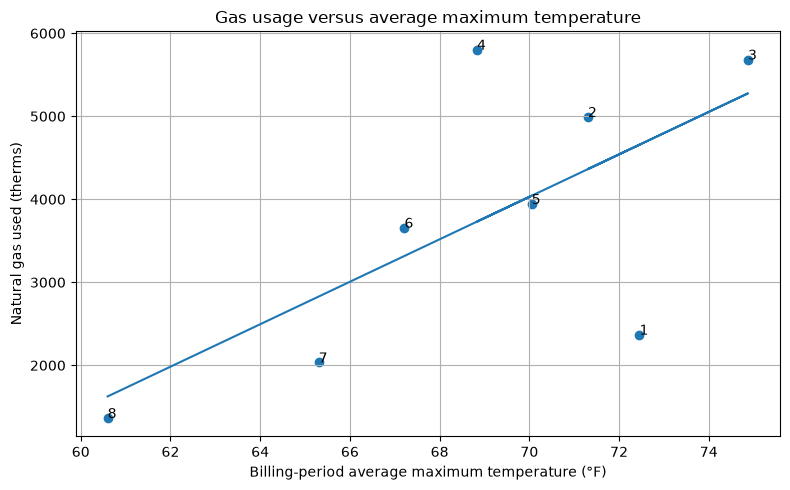

In [106]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = gas_df[["average_humidity", "natural_gas_used_therms"]].dropna()

x = plot_data["average_humidity"]
y = plot_data["natural_gas_used_therms"]

slope, intercept = np.polyfit(x,y,1)

plt.figure(figsize=(8,5))

plt.scatter(x,y)

plt.plot(
    x,
    slope * x + intercept
)

for index, row in plot_data.iterrows():
    plt.annotate(
        str(index + 1),
        (
            row["average_humidity"],
            row["natural_gas_used_therms"]
        )
    )

plt.xlabel("Billing-period average maximum temperature (°F)")
plt.ylabel("Natural gas used (therms)")
plt.title("Gas usage versus average maximum temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

In [117]:
regression_table_electric = create_regression_table(dataframe=electric_df, target_column="onpeak_electricity_used_kwh")
regression_table_electric

,weather_varable,correlation_r,r_squared,slope,intercept,p_value,billing_periods
0,average_snow_depth,0.955,0.913,3502.218,20086.070,0.000,8
1,average_dew_point,-0.916,0.839,-332.077,33287.635,0.001,8
2,average_tmin,-0.896,0.802,-282.641,31691.437,0.003,8
3,average_tmax,-0.859,0.738,-247.817,35415.639,0.006,8
4,total_snowfall,0.583,0.340,522.449,21308.916,0.129,8
5,total_precipitation,-0.497,0.247,-1515.328,27497.702,0.210,8
6,average_humidity,0.289,0.083,309.128,2422.852,0.488,8
7,average_max_humidity,-0.261,0.068,-493.104,64815.869,0.532,8
8,max_wind_gusts,0.091,0.008,63.930,19029.539,0.831,8
9,average_max_wind_speed,0.054,0.003,112.855,21030.306,0.899,8


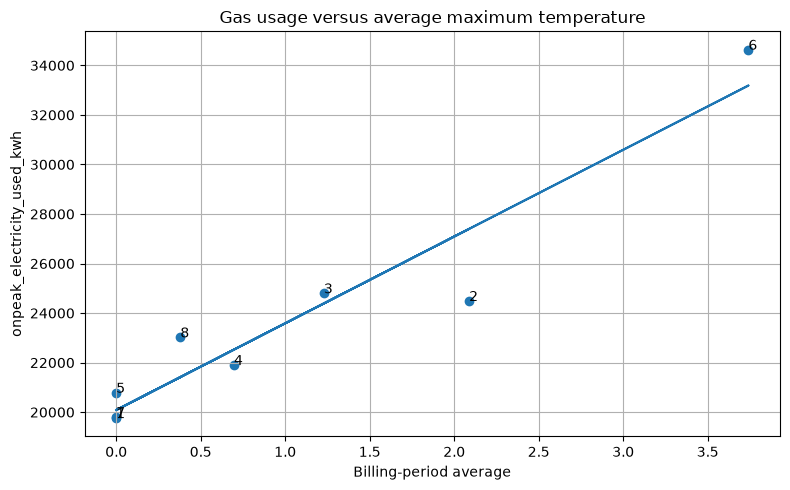

In [115]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = electric_df[["average_snow_depth", "onpeak_electricity_used_kwh"]].dropna()

x = plot_data["average_snow_depth"]
y = plot_data["onpeak_electricity_used_kwh"]

slope, intercept = np.polyfit(x,y,1)

plt.figure(figsize=(8,5))

plt.scatter(x,y)

plt.plot(
    x,
    slope * x + intercept
)

for index, row in plot_data.iterrows():
    plt.annotate(
        str(index + 1),
        (
            row["average_snow_depth"],
            row["onpeak_electricity_used_kwh"]
        )
    )

plt.xlabel("Billing-period average")
plt.ylabel("onpeak_electricity_used_kwh")
plt.title("Gas usage versus average maximum temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

## check to see if Normalize gas usage by billing-period length will show anything

In [84]:
gas_df["therms_per_day"] = (
    gas_df["natural_gas_used_therms"] / gas_df["gas_billing_days"]
)

regression_total = create_regression_table(
    dataframe=gas_df,
    target_column="natural_gas_used_therms"
)

regression_daily = create_regression_table(
    dataframe=gas_df,
    target_column="therms_per_day"
)

regression_total

,weather_varable,correlation_r,r_squared,slope,intercept,p_value,billing_periods
0,average_tmax,-0.976,0.952,-98.831,8431.715,0.000,8
1,average_tmin,-0.960,0.922,-105.973,6755.959,0.000,8
2,average_dew_point,-0.952,0.907,-120.570,7247.262,0.000,8
3,average_snow_depth,0.840,0.705,1155.119,2584.307,0.009,8
4,total_snowfall,0.723,0.522,223.678,2729.339,0.043,8
5,average_humidity,0.676,0.457,255.770,-13874.324,0.066,8
6,weather_days_found,0.520,0.271,282.715,-4751.141,0.186,8
7,total_precipitation,-0.412,0.170,-392.855,4746.813,0.311,8
8,average_max_wind_speed,0.243,0.059,184.384,-564.664,0.562,8
9,average_max_humidity,0.107,0.011,69.942,-2117.082,0.801,8


In [85]:
regression_daily

,weather_varable,correlation_r,r_squared,slope,intercept,p_value,billing_periods
0,average_tmax,-0.995,0.989,-3.189,273.159,0.000,8
1,average_tmin,-0.995,0.989,-3.474,220.635,0.000,8
2,average_dew_point,-0.992,0.985,-3.977,237.465,0.000,8
3,average_snow_depth,0.887,0.787,38.624,83.130,0.003,8
4,total_snowfall,0.667,0.445,6.537,92.195,0.071,8
5,average_humidity,0.620,0.385,7.433,-390.154,0.101,8
6,total_precipitation,-0.455,0.207,-13.736,156.991,0.257,8
7,weather_days_found,0.338,0.114,5.815,-53.009,0.413,8
8,average_max_wind_speed,0.216,0.046,5.174,0.919,0.608,8
9,average_max_humidity,0.063,0.004,1.311,11.805,0.881,8


## Calculate expected weather coverage percentage

In [86]:
gas_df["weather_coverage_pct"] = (
    gas_df["weather_days_found"] / gas_df["gas_billing_days"] *100
)

gas_df_valid = gas_df[
    gas_df["weather_coverage_pct"] >= 90
].copy()

gas_df_valid

,gas_read_date,gas_billing_days,natural_gas_used_therms,heating_degree_days_gas,cooling_degree_days_gas,gas_start_date,average_tmax,average_tmin,average_humidity,average_max_humidity,average_dew_point,average_max_wind_speed,max_wind_gusts,total_precipitation,average_snow_depth,total_snowfall,weather_days_found,missing_weather_days,therms_per_day,weather_coverage_pct
1,2025-12-10,34,4992.0,1092,0,2025-11-07,39.400624,23.072803,71.306372,83.882353,24.378520,22.028114,74.520004,2.21,1.970588,14.9,34.0,0.0,146.823529,100.000000
2,2026-01-13,34,5682.6,1299,0,2025-12-11,32.227665,16.764706,74.873775,85.411765,19.706535,23.888265,72.360000,2.07,1.264706,4.3,34.0,0.0,167.135294,100.000000
3,2026-02-10,28,5801.4,1429,0,2026-01-14,21.955411,2.940022,68.833333,81.285714,5.819060,23.509966,72.000000,0.79,3.500000,9.6,28.0,0.0,207.192857,100.000000
4,2026-03-11,29,3941.5,839,0,2026-02-11,44.904950,24.958814,70.051724,84.068966,26.205018,23.368743,74.159996,1.48,0.482759,1.0,29.0,0.0,135.913793,100.000000
5,2026-04-12,32,3657.4,719,0,2026-03-12,49.453125,28.181288,67.216146,83.250000,29.443834,27.603103,84.600000,4.07,0.718750,6.0,32.0,0.0,114.293750,100.000000
6,2026-05-11,29,2034.0,275,9,2026-04-13,62.722597,41.238338,65.303160,83.206897,39.926833,24.287795,78.479996,6.25,0.000000,0.0,29.0,0.0,70.137931,100.000000
7,2026-06-10,30,1364.3,61,137,2026-05-12,73.698986,51.362811,60.599138,79.517241,48.001298,21.601256,74.159996,1.33,0.000000,0.0,29.0,1.0,45.476667,96.666667


In [88]:
regression_valid = create_regression_table(
    dataframe=gas_df_valid,
    target_column="natural_gas_used_therms"
)

regression_valid

,weather_varable,correlation_r,r_squared,slope,intercept,p_value,billing_periods
0,average_tmax,-0.981,0.963,-96.151,8380.154,0.000,7
1,average_tmin,-0.956,0.915,-104.597,6741.667,0.001,7
2,average_dew_point,-0.946,0.896,-119.801,7236.075,0.001,7
3,average_humidity,0.875,0.766,331.576,-18725.877,0.010,7
4,average_snow_depth,0.821,0.674,1129.400,2644.196,0.024,7
5,total_snowfall,0.689,0.475,213.806,2831.277,0.087,7
6,average_max_humidity,0.515,0.265,456.131,-33909.584,0.237,7
7,total_precipitation,-0.442,0.196,-399.181,4962.614,0.320,7
8,weather_days_found,0.430,0.185,290.320,-4992.215,0.335,7
9,max_wind_gusts,-0.387,0.150,-150.914,15357.094,0.391,7


## Check for impossible or questionable values

In [89]:
print(
    gas_df[
        [
            "gas_read_date",
            "gas_billing_days",
            "natural_gas_used_therms",
            "average_tmax",
            "average_tmin",
            "weather_days_found"
        ]
    ].describe()
)

gas_df["average_tmax"] >= gas_df["average_tmin"]

temperature_issues = gas_df[gas_df["average_tmax"] < gas_df["average_tmin"]]

print(temperature_issues)

             gas_read_date  gas_billing_days  natural_gas_used_therms  \
count                    8          8.000000                 8.000000   
mean   2026-02-24 06:00:00         30.500000              3730.300000   
min    2025-11-06 00:00:00         28.000000              1364.300000   
25%    2026-01-04 12:00:00         28.750000              2285.400000   
50%    2026-02-24 12:00:00         29.500000              3799.450000   
75%    2026-04-19 06:00:00         32.500000              5164.650000   
max    2026-06-10 00:00:00         34.000000              5801.400000   
std                    NaN          2.507133              1693.294344   

       average_tmax  average_tmin  weather_days_found  
count      8.000000      8.000000            8.000000  
mean      47.570423     28.551301           30.000000  
min       21.955411      2.940022           25.000000  
25%       37.607384     21.495779           28.750000  
50%       47.179038     26.570051           29.000000  
75%   

In [93]:
from scipy.stats import linregress

sensitivity_results = []

analysis_data = gas_df[
    ["average_tmax", "natural_gas_used_therms"]
].dropna().reset_index(drop=True)

for excluded_index in analysis_data.index:
    test_data = analysis_data.drop(index=excluded_index)

    result = linregress(
        test_data["average_tmax"],
        test_data["natural_gas_used_therms"]
    )

    sensitivity_results.append({
        "excluded_row": excluded_index + 1,
        "correlation_r": result.rvalue,
        "r_squared": result.rvalue ** 2
    })

sensitivity_table = pd.DataFrame(sensitivity_results)

print(sensitivity_table)

   excluded_row  correlation_r  r_squared
0             1      -0.981448   0.963241
1             2      -0.979988   0.960377
2             3      -0.976930   0.954392
3             4      -0.980843   0.962052
4             5      -0.975590   0.951775
5             6      -0.975939   0.952458
6             7      -0.972313   0.945394
7             8      -0.967299   0.935667


In [94]:
print(gas_df.duplicated(
    subset=["gas_start_date", "gas_read_date"]
).sum())

print(gas_df.isna().sum())

print(
    gas_df[
        [
            "gas_billing_days",
            "weather_days_found"
        ]
    ]
)

0
gas_read_date              0
gas_billing_days           0
natural_gas_used_therms    0
heating_degree_days_gas    0
cooling_degree_days_gas    0
gas_start_date             0
average_tmax               0
average_tmin               0
average_humidity           0
average_max_humidity       0
average_dew_point          0
average_max_wind_speed     0
max_wind_gusts             0
total_precipitation        0
average_snow_depth         0
total_snowfall             0
weather_days_found         0
missing_weather_days       0
therms_per_day             0
weather_coverage_pct       0
dtype: int64
   gas_billing_days  weather_days_found
0                28                25.0
1                34                34.0
2                34                34.0
3                28                28.0
4                29                29.0
5                32                32.0
6                29                29.0
7                30                29.0


In [95]:
for _, row in gas_df.iterrows():
    expected_dates = pd.date_range(
        row["gas_start_date"],
        row["gas_read_date"],
        freq="D"
    )

    missing = expected_dates.difference(weather_df["DATE"])

    if len(missing):
        print(
            f"{row['gas_start_date'].date()} to "
            f"{row['gas_read_date'].date()}"
        )
        print(missing)
        print()

2025-10-10 to 2025-11-06
DatetimeIndex(['2025-10-10', '2025-10-11', '2025-10-12'], dtype='datetime64[us]', freq='D')

2026-05-12 to 2026-06-10
DatetimeIndex(['2026-06-10'], dtype='datetime64[us]', freq='D')



## Ice Depth Correlation

In [26]:
regression_table_ice = create_regression_table(dataframe=ice_df, target_column="ice_depth_zone__9")
regression_table_ice

,weather_varable,correlation_r,r_squared,slope,intercept,p_value,billing_periods
0,average_max_humidity,0.195,0.038,0.014,0.240,0.503,14
1,total_snowfall,-0.182,0.033,-0.002,1.460,0.533,14
2,average_tmin,-0.156,0.024,-0.002,1.471,0.594,14
3,average_humidity,0.152,0.023,0.007,0.969,0.604,14
4,average_dew_point,-0.149,0.022,-0.002,1.478,0.611,14
5,average_tmax,-0.144,0.021,-0.002,1.493,0.622,14
6,average_max_wind_speed,-0.142,0.020,-0.009,1.634,0.628,14
7,average_snow_depth,-0.114,0.013,-0.014,1.447,0.697,14
8,max_wind_gusts,-0.109,0.012,-0.002,1.562,0.710,14
9,weather_days_found,-0.073,0.005,-0.000,1.442,0.804,14
